### <div style="background-color:blue; color:white; padding:10px;"> Load both predictions </div>

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

before_df = pd.read_csv("../Prediction/EPIC/P01_04_before_propagation.csv")
after_df = pd.read_csv("../Prediction/EPIC/P01_04_after_propagation.csv")
gt_df = pd.read_csv("../Labels/EPIC/P01_04_labels.csv")
before = before_df.drop(columns=["frame_id"]).values
after = after_df.drop(columns=["frame_id"]).values
gt = gt_df.drop(columns=["frame_id"]).values

### <div style="background-color:blue; color:white; padding:10px;">Plot comparison</div>

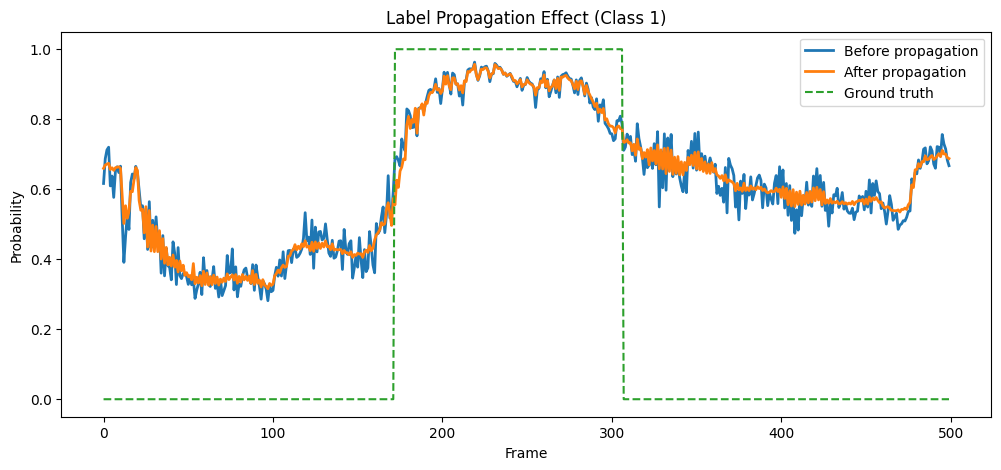

In [89]:
action_class = 1   # change this to any class index
start = 0
end = 500
plt.figure(figsize=(12,5))
plt.plot(before[start:end, action_class], label="Before propagation", linewidth=2)
plt.plot(after[start:end, action_class], label="After propagation", linewidth=2)
plt.plot(gt[start:end, action_class], label="Ground truth", linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Probability")
plt.title(f"Label Propagation Effect (Class {action_class})")
plt.legend()
plt.show()

### <div style="background-color:blue; color:white; padding:10px;"> Find frames improved by propagation </div>

In [90]:
diff = after - before
improved_frames = diff.mean(axis=1)
top_improved = improved_frames.argsort()[-10:]
print("Most improved frames:", top_improved)

Most improved frames: [6061 2504 3144 2170 1088 6119 1336 4569 1579 2204]


### <div style="background-color:blue; color:white; padding:10px;"> Show table comparison </div>

In [91]:
rows = []
for frame in top_improved:   
    rows.append({
        "Frame": frame,
        "Before": before[frame].max(),
        "After": after[frame].max(),
        "Ground Truth": gt[frame].max()
    })
comparison_df = pd.DataFrame(rows)
print(comparison_df)

   Frame    Before     After  Ground Truth
0   6061  0.914930  0.900234           1.0
1   2504  0.965127  0.963891           1.0
2   3144  0.866595  0.856604           1.0
3   2170  0.712774  0.634798           0.0
4   1088  0.906437  0.891992           0.0
5   6119  0.972840  0.970493           1.0
6   1336  0.899747  0.868762           1.0
7   4569  0.842808  0.845966           1.0
8   1579  0.878732  0.861610           1.0
9   2204  0.855509  0.780773           0.0


In [92]:
import pandas as pd
import matplotlib.pyplot as plt

before = pd.read_csv("../Prediction/EPIC/P01_04_before_propagation.csv").drop(columns=["frame_id"]).values
after = pd.read_csv("../Prediction/EPIC/P01_04_after_propagation.csv").drop(columns=["frame_id"]).values

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


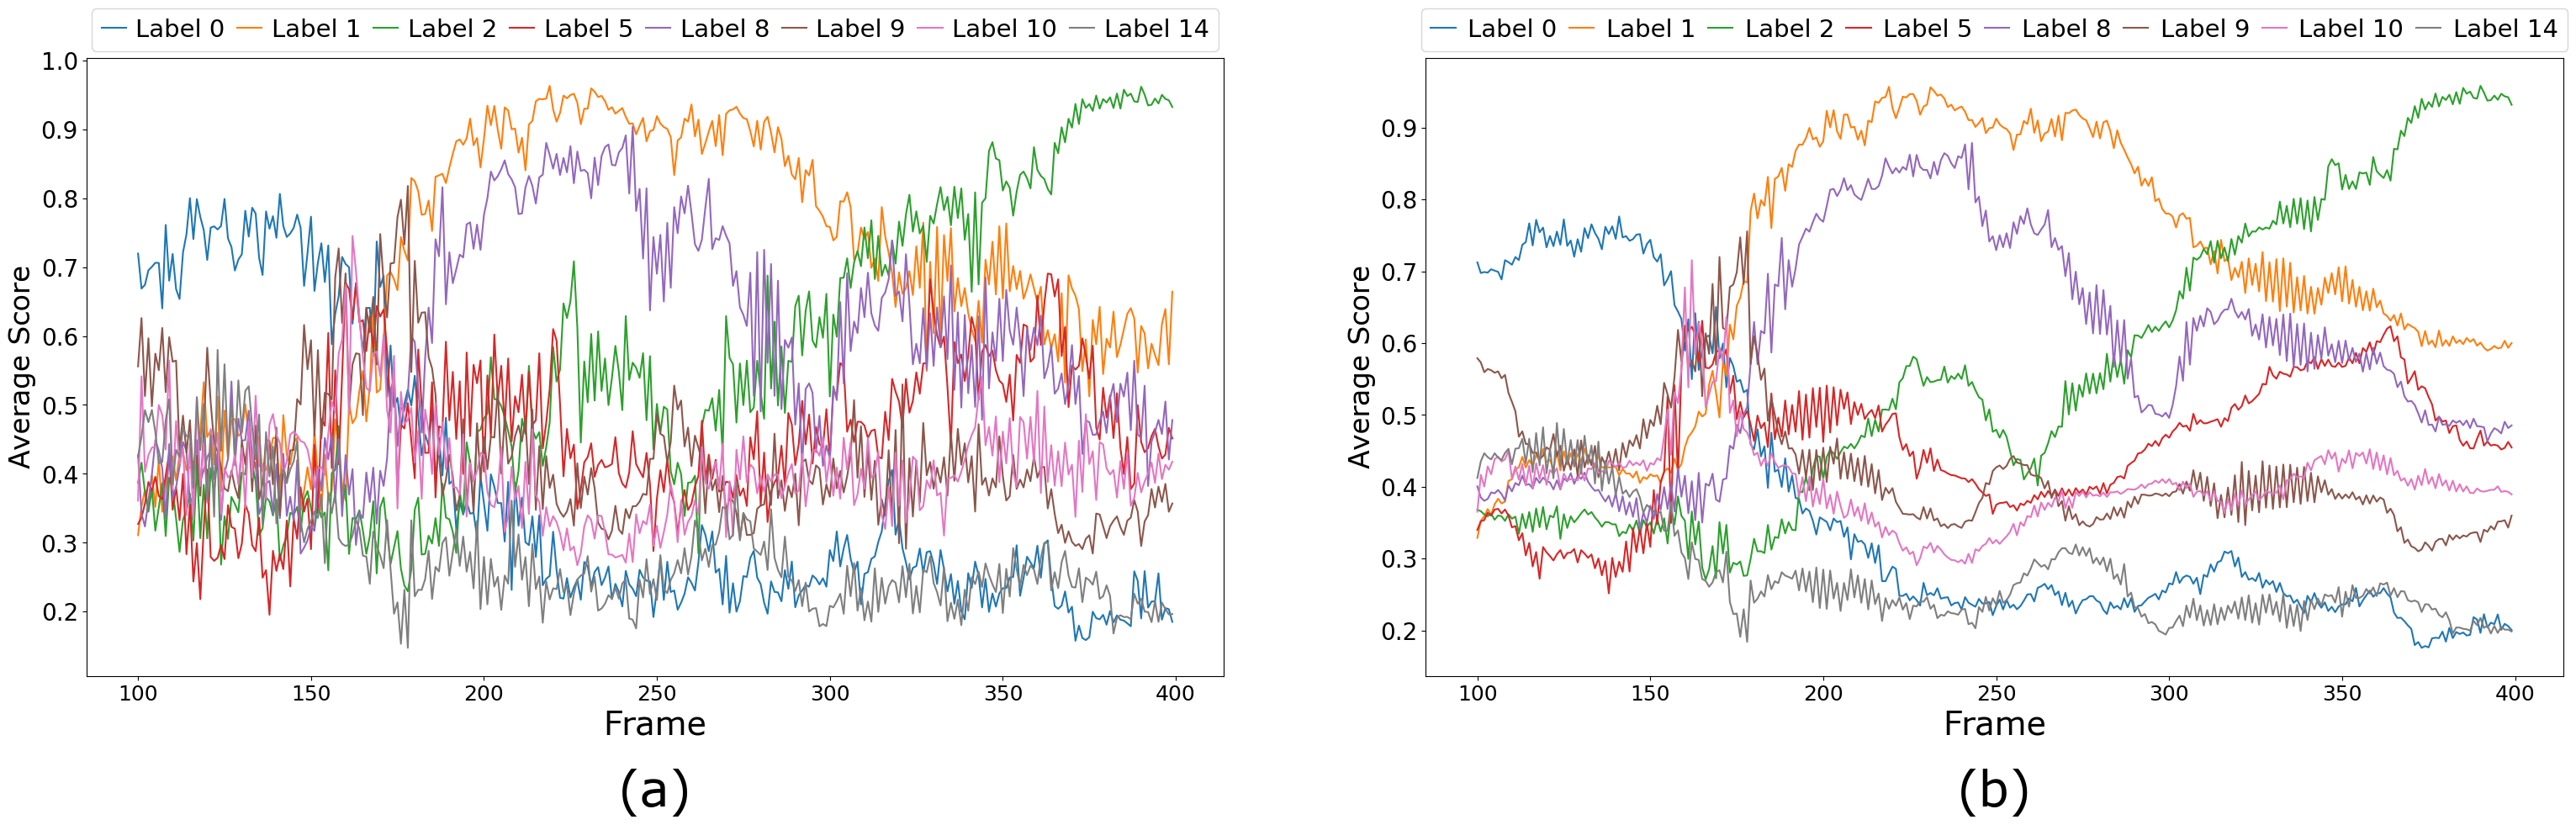

In [127]:
start = 100
end = 400
before_seg = before[start:end]
after_seg = after[start:end]

class_ids=[0,1,2,5,8,9,10,14]
frames = range(start, end)

plt.figure(figsize=(32, 10))

# -------- BEFORE --------
plt.subplot(1,2,1)
for c in class_ids:
    plt.plot(frames, before_seg[:, c], label=f"Label {c}")
plt.xlabel("Frame", fontsize=28, fontfamily='Verdana')
plt.ylabel("Average Score" , fontsize=24, fontfamily='Verdana')
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10),
           ncol=len(class_ids), frameon=True, fontsize=21,
           columnspacing=0.5, handlelength=1.0, handletextpad=0.4)
plt.grid(False)
plt.gca().set_title("")  # remove title
plt.gca().text(0.5, -0.15, "(a)",
               transform=plt.gca().transAxes,
               ha='center', va='top', fontsize=42, fontfamily='Verdana')

# -------- AFTER --------
plt.subplot(1,2,2)
for c in class_ids:
    plt.plot(frames, after_seg[:, c], label=f"Label {c}")
plt.xlabel("Frame", fontsize=28, fontfamily='Verdana')
plt.ylabel("Average Score", fontsize=24, fontfamily='Verdana')
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10),
           ncol=len(class_ids), frameon=True, fontsize=21,
           columnspacing=0.5, handlelength=1.0, handletextpad=0.5)
plt.grid(False)
plt.gca().set_title("")  # remove title
plt.gca().text(0.5, -0.15, "(b)",
               transform=plt.gca().transAxes,
               ha='center', va='top', fontsize=42, fontfamily='Verdana')

plt.tight_layout()
plt.savefig("P01_04_qualitative_smoothed.eps", format='eps', dpi=1000, bbox_inches='tight')
plt.show()